# Transformer vs CNN — L=4 validation, observables, and scaling
Compares the factored-attention transformer symmetric block against the global-kernel CNN (and a GELU/4d transformer variant). Data: `results/nqs` + `results/ed`. json+numpy+matplotlib.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
NQS, ED = Path("../results/nqs"), Path("../results/ed")
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)

ARMS  = ["cnn", "tf", "tfg"]
LABEL = {"cnn": "CNN", "tf": "Transformer", "tfg": "Transformer (GELU/4d)", "v2": "v2 full-transformer"}
COLOR = {"cnn": "C0", "tf": "C1", "tfg": "C2", "v2": "C3"}

In [2]:
def load(L, hz, arm):
    p = NQS / f"G-equiv_1_L{L}_hx0.00_hz{hz:.2f}_{arm}.json"
    return json.load(open(p)) if p.exists() else None

real  = lambda xs: np.array([complex(x).real for x in xs])
edE0  = lambda L, hz: json.load(open(ED / f"ed_L{L}_hx0.00_hz{hz:.2f}.json"))["E0"]
ed_mz = lambda L, hz: json.load(open(ED / f"ed_L{L}_hx0.00_hz{hz:.2f}.json"))["magnetization_Z_mean"]
mz    = lambda d: float(np.mean(d["order_params"]["magnetization_Zmean"][-1]))   # bulk <sigma^z>, last callback
bp    = lambda d: float(d["order_params"]["Bp_mean"][-1])                         # <B_p>, last callback
runmed = lambda x, w=11: np.array([np.median(x[max(0, i - w + 1):i + 1]) for i in range(len(x))])

In [3]:
# --- knobs ---
L_LEARN  = 4
HZ_LEARN = 0.15                              # field for the learning-curve panel
HZ_OBS   = [0.10, 0.15, 0.20, 0.25, 0.30]    # fields for observables-vs-hz (all have ED)

## 1. Learning curves & stability
Convergence speed to ED (left) and V-score (right, lower = more stable).

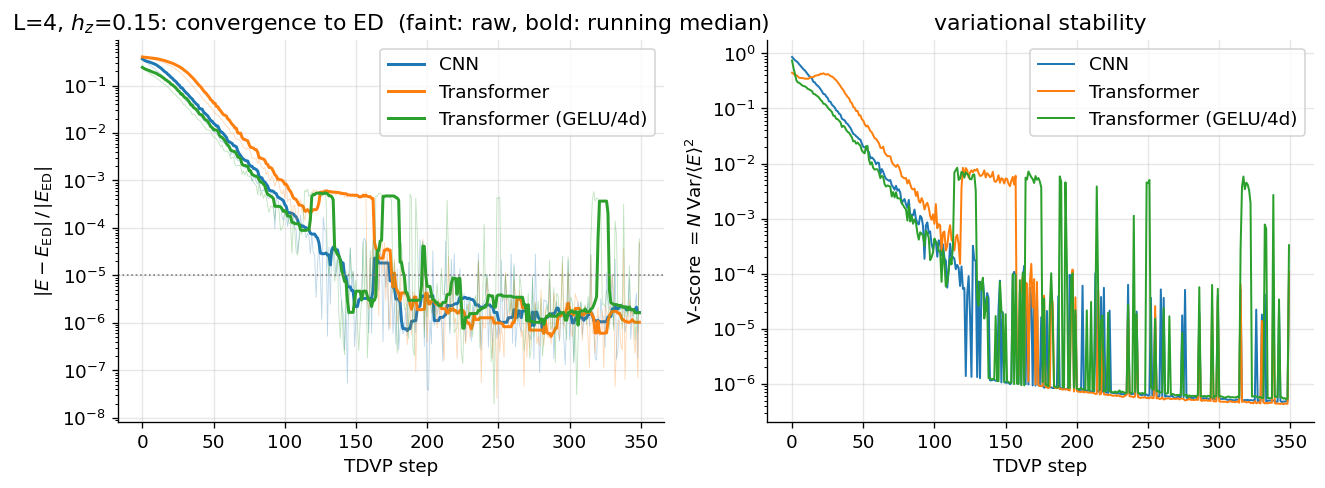

In [4]:
# 1. Learning curves (convergence speed + how close to ED) and V-score (stability).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for arm in ARMS:
    d = load(L_LEARN, HZ_LEARN, arm)
    if d is None:
        continue
    E = real(d["energy"]); s = np.arange(len(E))
    rel = np.abs(E - edE0(L_LEARN, HZ_LEARN)) / abs(edE0(L_LEARN, HZ_LEARN))
    ax1.plot(s, rel, color=COLOR[arm], lw=0.5, alpha=0.3)                 # raw per-step (MC noise)
    ax1.plot(s, runmed(rel), color=COLOR[arm], lw=1.8, label=LABEL[arm])  # running median = true descent
    ax2.plot(s, real(d["Vscore"]), color=COLOR[arm], lw=1.2, label=LABEL[arm])
ax1.axhline(1e-5, color="grey", ls=":", lw=1)
ax1.set(xlabel="TDVP step", ylabel=r"$|E-E_{\mathrm{ED}}|\,/\,|E_{\mathrm{ED}}|$", yscale="log",
        title=f"L={L_LEARN}, $h_z$={HZ_LEARN}: convergence to ED  (faint: raw, bold: running median)")
ax1.legend()
ax2.set(xlabel="TDVP step", ylabel=r"V-score $=N\,\mathrm{Var}/\langle E\rangle^2$", yscale="log",
        title="variational stability")
ax2.legend()
fig.tight_layout()
fig.savefig(FIG / "05_learning_curves.png", dpi=200, bbox_inches="tight")

## 2. Observables vs field
All architectures should track ED for $\langle\sigma^z\rangle$ and hold $\langle B_p\rangle=1$.

In [ ]:
# 2. Observables vs field: bulk magnetization <sigma^z> (rises with hz) and the plaquette
#    stabilizer <B_p> (exactly 1 on this cut -> a contamination check).
fig, (axz, axb) = plt.subplots(1, 2, figsize=(11, 4.2))
for arm in ARMS:
    hs = [hz for hz in HZ_OBS if load(L_LEARN, hz, arm)]
    axz.plot(hs, [mz(load(L_LEARN, hz, arm)) for hz in hs], "o-", color=COLOR[arm], ms=5, label=LABEL[arm])
    axb.plot(hs, [bp(load(L_LEARN, hz, arm)) for hz in hs], "o-", color=COLOR[arm], ms=5, label=LABEL[arm])
axz.plot(HZ_OBS, [ed_mz(L_LEARN, hz) for hz in HZ_OBS], "k--", lw=1.2, label="ED")
axz.set(xlabel="$h_z$", ylabel=r"$\langle \sigma^z\rangle$ (bulk)", title="magnetization")
axz.legend()
axb.axhline(1.0, color="grey", ls=":", lw=1); axb.set_ylim(0.99, 1.003)
axb.set(xlabel="$h_z$", ylabel=r"$\langle B_p\rangle$", title=r"plaquette stabilizer (exact $=1$; all within 0.1%)")
axb.legend()
fig.tight_layout()
fig.savefig(FIG / "05_observables_vs_hz.png", dpi=200, bbox_inches="tight")

## 3. Model size & compute vs system size
Edit `TF=dict(...)` to explore transformer configs.

In [ ]:
# Closed-form parameter counts (validated to the digit against sim_params.n_params of every run).
# block1 = the non-invariant edge CNN (local kernel -> L-independent, shared by both arms) = 448.
def cnn_params(L, c_inv=(16, 8, 1), block1=448):
    g = (L - 1) ** 2                                   # global-kernel taps = # plaquettes
    return block1 + sum(co * ci * g + co for ci, co in zip(c_inv, c_inv[1:]))

def tf_params(L, n_layers=2, n_heads=2, d_model=8, d_ffn=16, C=16, block1=448):
    d, R = d_model, (2 * L - 3) ** 2                   # R = # relative displacements (OBC, no wrap)
    embed = (C + 1) * d
    layer = 2 * d * d + 2 * d * d_ffn + 7 * d + d_ffn + n_heads * R   # attn(V,W,alpha) + FFN + 2xLN
    head  = d * d + 3 * d                              # out-LN + Dense(d->d) + log-cosh
    return block1 + embed + n_layers * layer + head

# --- transformer architecture for the scaling curve (edit to explore) ---
TF = dict(n_layers=2, n_heads=2, d_model=8, d_ffn=16)

# steady-state wall-clock per TDVP step (skip JIT steps 0-1)
def sstep(L, hz, arm, skip=2):
    d = load(L, hz, arm)
    if d is None or len(d["energy"]) <= skip:
        return None
    g = lambda k: float(np.median([float(x) for x in d[k][skip:]]))
    return g("t_sample") + g("t_grad") + g("t_sr")

In [ ]:
# 3. How model size and compute scale with system size L. CNN grows as ~136*(L-1)^2 (a full kernel
#    per plaquette); the transformer factorizes that kernel, so its params/compute grow far slower.
Ls = np.arange(4, 15)
tf_curve  = [tf_params(L, **TF) for L in Ls]
cnn_curve = [cnn_params(L) for L in Ls]

# measured n_params (markers validate the formulas)
P_meas = {"cnn": {4: 1681, 6: 3857}, "tf": {4: 1684, 6: 1908, 8: 2260, 10: 2740}}
# measured s/step (cnn L8/L10 from the prior CNN sweep in CLAUDE.md, shown hollow)
T_cnn_prior = {8: 6.7, 10: 20.4}

fig, (axp, axt) = plt.subplots(1, 2, figsize=(11, 4.2))
axp.plot(Ls, cnn_curve, color=COLOR["cnn"], label="CNN (16,8,1)")
axp.plot(Ls, tf_curve,  color=COLOR["tf"],
         label=f"Transformer (L{TF['n_layers']} h{TF['n_heads']} d{TF['d_model']} ff{TF['d_ffn']})")
for arm in ("cnn", "tf"):
    axp.scatter(list(P_meas[arm]), list(P_meas[arm].values()), color=COLOR[arm], zorder=5, s=30)
axp.set(xlabel="system size $L$", ylabel="# parameters", title="model size vs $L$")
axp.legend(fontsize=9)

for arm, col in (("cnn", COLOR["cnn"]), ("tf", COLOR["tf"])):
    Lm = [L for L in (4, 6, 8, 10) if sstep(L, 0.15, arm)]
    axt.plot(Lm, [sstep(L, 0.15, arm) for L in Lm], "o-", color=col, ms=6, label=LABEL[arm])
axt.plot(list(T_cnn_prior), list(T_cnn_prior.values()), "o", mfc="none", mec=COLOR["cnn"],
         ms=6, label="CNN (prior sweep)")
axt.set(xlabel="system size $L$", ylabel="wall-clock s / TDVP step", yscale="log",
        title="compute vs $L$  (tf overtakes CNN by L=6)")
axt.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "05_scaling.png", dpi=200, bbox_inches="tight")

## 4. v2 full-transformer vs ED
Learning curves and relative error for the full-pipeline transformer (Block 1 spatial attention → Wilson fusion → Block 2 factored attention), L=4.

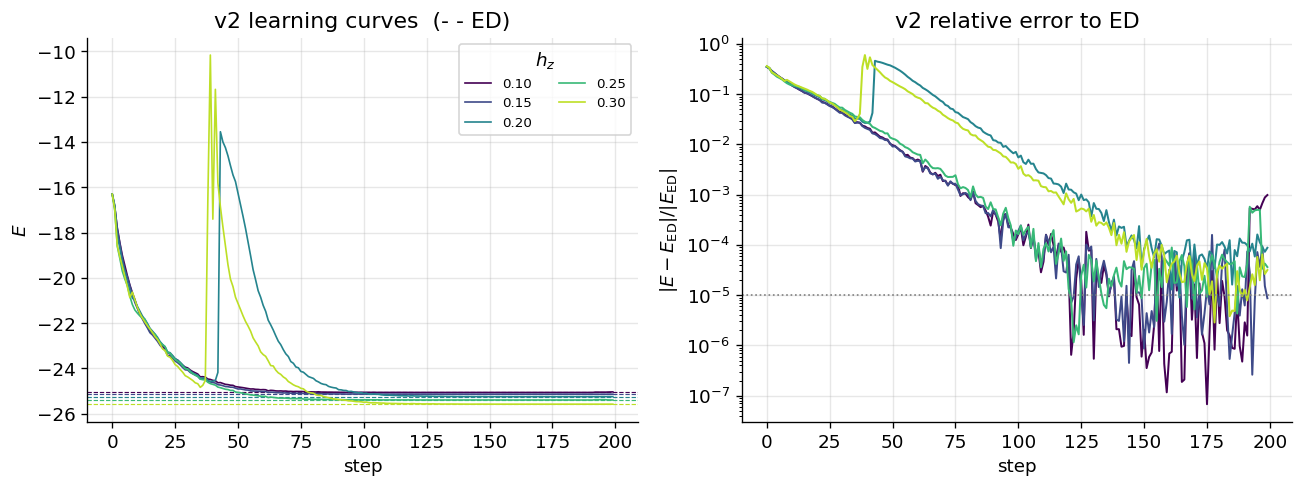

In [5]:
# 4. v2 full-transformer vs ED. Learning curves (E vs step, ED dashed) and rel-err vs step,
#    matching the 01_L4_vs_ED style. v2 = full-pipeline transformer (n1=2, n2=2, d=8).
HZ_ED = [0.10, 0.15, 0.20, 0.25, 0.30]
fig, (axE, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
for c, hz in zip(plt.cm.viridis(np.linspace(0, 0.9, len(HZ_ED))), HZ_ED):
    d = load(L_LEARN, hz, "v2")
    if d is None:
        continue
    E = real(d["energy"]); s = np.arange(len(E)); E0 = edE0(L_LEARN, hz)
    axE.plot(s, E, color=c, lw=1, label=f"{hz:.2f}")
    axE.axhline(E0, color=c, ls="--", lw=0.7)
    axR.plot(s, np.abs(E - E0) / abs(E0), color=c, lw=1.2)
axE.set(xlabel="step", ylabel="$E$", title="v2 learning curves  (- - ED)")
axE.legend(title="$h_z$", ncol=2, fontsize=8)
axR.axhline(1e-5, color="grey", ls=":", lw=1)
axR.set(xlabel="step", ylabel=r"$|E-E_{\mathrm{ED}}|/|E_{\mathrm{ED}}|$", yscale="log",
        title="v2 relative error to ED")
fig.tight_layout()
fig.savefig(FIG / "05_v2_vs_ED.png", dpi=200, bbox_inches="tight")

## 5. Is v2 comparable to CNN?
Final tail-median relative error vs $h_z$ — v2 against the CNN baseline.

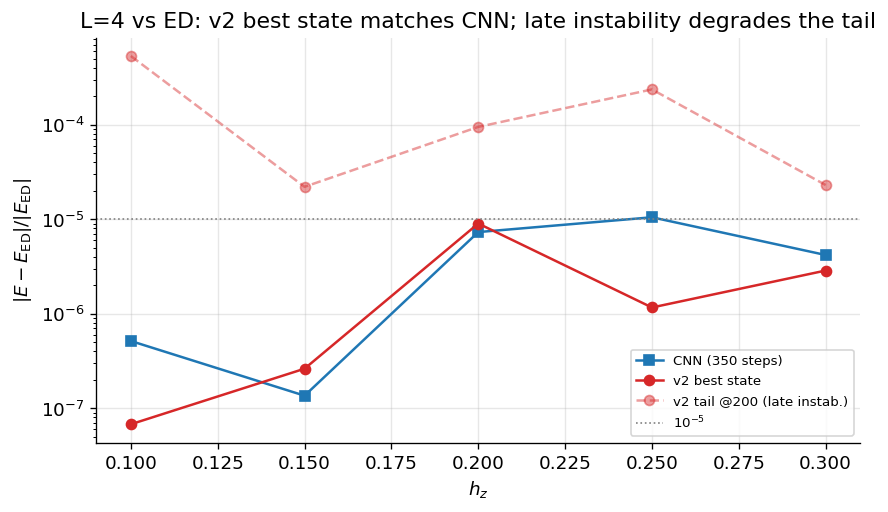

In [6]:
# 5. Is v2 comparable to CNN? v2 REACHES CNN-level accuracy (best state along the run) at
#    every hz, but a late-training SR instability degrades the step-200 tail. Show both.
TAIL = 10
def _E(L, hz, arm):
    d = load(L, hz, arm)
    return None if d is None else real(d["energy"])
def tail_relerr(L, hz, arm):
    E = _E(L, hz, arm)
    return None if E is None or E.size == 0 else abs(np.median(E[-TAIL:]) - edE0(L, hz)) / abs(edE0(L, hz))
def best_relerr(L, hz, arm):
    E = _E(L, hz, arm)
    return None if E is None or E.size == 0 else float(np.min(np.abs(E - edE0(L, hz)))) / abs(edE0(L, hz))
fig, ax = plt.subplots(figsize=(7.4, 4.4))
hc = [hz for hz in HZ_ED if tail_relerr(L_LEARN, hz, "cnn") is not None]
if hc:
    ax.plot(hc, [tail_relerr(L_LEARN, hz, "cnn") for hz in hc], "s-", color=COLOR["cnn"], ms=6, label="CNN (350 steps)")
hv = [hz for hz in HZ_ED if tail_relerr(L_LEARN, hz, "v2") is not None]
if hv:
    ax.plot(hv, [best_relerr(L_LEARN, hz, "v2") for hz in hv], "o-", color=COLOR["v2"], ms=6, label="v2 best state")
    ax.plot(hv, [tail_relerr(L_LEARN, hz, "v2") for hz in hv], "o--", color=COLOR["v2"], ms=6, alpha=0.45, label="v2 tail @200 (late instab.)")
ax.axhline(1e-5, color="grey", ls=":", lw=1, label=r"$10^{-5}$")
ax.set(xlabel="$h_z$", ylabel=r"$|E-E_{\mathrm{ED}}|/|E_{\mathrm{ED}}|$", yscale="log",
       title="L=4 vs ED: v2 best state matches CNN; late instability degrades the tail")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "05_v2_vs_cnn_relerr.png", dpi=200, bbox_inches="tight")